In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up two levels (from numerics to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# # Ensure packages are installed
# for pkg in [
#     "PauliPropagation", "Plots", "LinearAlgebra", "ProgressMeter", "Distributions",
#     "Random", "Optimisers", "ReverseDiff", "MAT", "BenchmarkTools", "IterTools", "StatsBase", "LaTeXStrings", "Measures", "CSV", "DataFrames", "JSON3", "Dates"
# ]
#     Pkg.add(pkg)
# end

In [2]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures, CSV, DataFrames, JSON3, Dates

# TFIM

## 8 qubits

In [12]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 8 

# target

## target hamiltonian
target_beta = 1
rng = MersenneTwister(42)
target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))
params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) * target_beta

## target state
targert_circuit, target_θ = paulistringtocircuit(target_H_paulis)
num_layers_target = 10
max_weight_target = nq
min_abs_coeff_target = 1e-20
target_eta = makethermalstate(nq, targert_circuit, target_θ, num_layers_target;
                                  max_weight=max_weight_target,
                                  min_abs_coeff=min_abs_coeff_target)
target_eta_matrix = paulistringtomatrix(target_eta)
target_probs = computesymmetriceigenvalues(target_eta_matrix)

# beta values 
weight_values = [nq, nq-2, nq-4, nq-6]
colors = [:dodgerblue, :seagreen, :orange, :crimson]

# learning rate
gamma = 0.2
# number of epochs
epochs = 1000
# stop when gradient is smaller than epsilon
epsilon = 1e-6

beta = rand(rng, Uniform(0, 10))      

# # Output path
# save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
# base_name = "targetTFIM_qbmTFIM_6qb_notrunc"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over maximum weight values
for (i, max_weight_qbm) in enumerate(weight_values)

    println("\n" * "="^60)
    @printf("Starting optimization for max weight = %d\n", max_weight_qbm)
    println("="^60)

    # QBM model
    rng = MersenneTwister(9)
    interaction = rand(rng, Uniform(-1, 1))
    field = rand(rng, Uniform(-1, 1))
    params = parameters(:tfim, nq; field_vals=Dict(:X => field), coupling_vals=Dict(:ZZ => interaction))
    qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta  
    ## truncation parameters
    num_layers_qbm = 10
    min_abs_coeff_qbm = 1e-10

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
        push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

        # create qbm state
        circuit, theta = paulistringtocircuit(qbm_H_paulis)
        rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # Compute and record gradient
        grads = computegradients(qbm_H_paulis, target_eta, rho)
        push!(grad_hist, abs.(grads))

        # Update parameters
        updatehamiltonian!(qbm_H_paulis, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 20 == 0
            @printf("  [w=%d | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    max_weight_qbm, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this maximum weight
    @printf("\nFinished max_weight = %d  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            max_weight_qbm, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # # ------------------------- #
    # # --- SAVE DATA TO FILE --- #
    # # ------------------------- #

    # # Save optimization histories as CSV
    # df = DataFrame(epoch = 1:length(qre_hist),
    #                qre = qre_hist,
    #                max_grad = [maximum(g) for g in grad_hist])
    # csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    # CSV.write(csv_path, df)
    # @printf("  → Saved CSV data to %s\n", csv_path)

    # # Collect metadata only once per run
    # metadata = Dict(
    #     "timestamp" => string(now()),
    #     "model_target" => "TFIM",
    #     "model_qbm" => "TFIM",
    #     "n_qubits" => nq,
    #     "beta_target" => target_beta,
    #     "beta_qbm" => beta,
    #     "beta_values" => beta_values,
    #     "learning_rate" => gamma,
    #     "epochs" => epochs,
    #     "epsilon" => epsilon,
    #     "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
    #                             "wij_xyz" => params_target.wij_xyz),
    #     "target_truncation" => Dict("max_weight" => max_weight_target,
    #                                 "min_abs_coeff" => min_abs_coeff_target,
    #                                 "num_layers" => num_layers_target),
    #     "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
    #                              "min_abs_coeff" => min_abs_coeff_qbm,
    #                              "num_layers" => num_layers_qbm)
    # )

    # json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    # JSON3.write(json_path, metadata; indent=2)
    # @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "max weight = $(max_weight_qbm)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "max weight = $(max_weight_qbm)", color = colors[i], lw = 3)
end


Starting optimization for max weight = 8
  [w=8 | epoch=  20]  QRE = 6.528376e-03   max|∇| = 3.019208e-02
  [w=8 | epoch=  40]  QRE = 8.176659e-06   max|∇| = 9.001626e-04
  [w=8 | epoch=  60]  QRE = 5.562642e-06   max|∇| = 2.799135e-05
  [w=8 | epoch=  80]  QRE = 5.652474e-06   max|∇| = 8.695021e-07
Converged: max gradient < epsilon

Finished max_weight = 8  → epochs: 80 | final QRE = 5.652474e-06 | final max|∇| = 8.695e-07
------------------------------------------------------------

Starting optimization for max weight = 6
  [w=6 | epoch=  20]  QRE = 6.549388e-03   max|∇| = 3.021940e-02
  [w=6 | epoch=  40]  QRE = 8.181952e-06   max|∇| = 9.011554e-04
  [w=6 | epoch=  60]  QRE = 5.568761e-06   max|∇| = 2.802801e-05
  [w=6 | epoch=  80]  QRE = 5.659123e-06   max|∇| = 8.707756e-07
Converged: max gradient < epsilon

Finished max_weight = 6  → epochs: 80 | final QRE = 5.659123e-06 | final max|∇| = 8.708e-07
------------------------------------------------------------

Starting optimizati

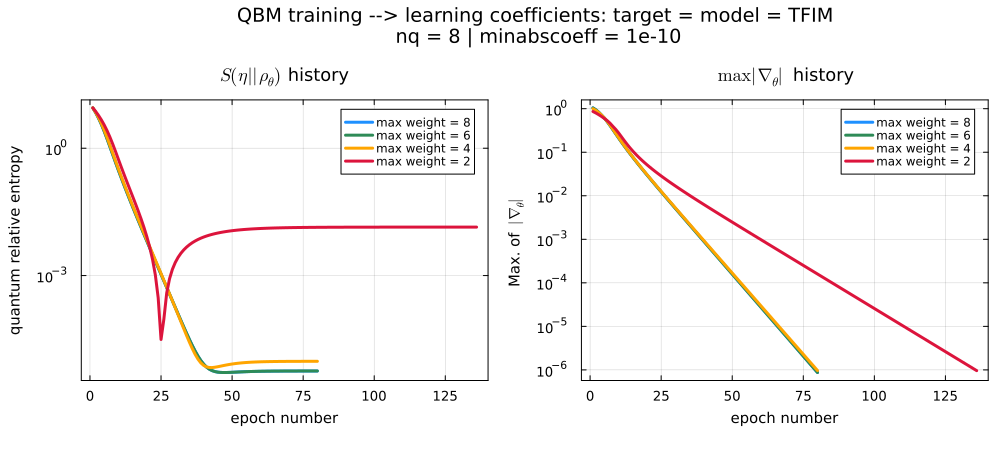

In [13]:
# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning coefficients: target = model = TFIM\n nq = 8 | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)

# Generic Hamiltonian

## 6 qubits

In [7]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 8 

# target

## target hamiltonian
target_beta = 1
rng = MersenneTwister(42)
field_scale = 0.5       # typical order of magnitude for 1-local terms
coupling_scale = 0.2    # typical order for 2-local terms
# Initialize all parameters randomly
params_target = parameters(
    :generic, nq;
    init = :randn,
    field_scale = field_scale,
    coupling_scale = coupling_scale,
    rng = rng
)
target_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) * target_beta

## target state
targert_circuit, target_θ = paulistringtocircuit(target_H_paulis)
num_layers_target = 10
max_weight_target = nq
min_abs_coeff_target = 1e-20
target_eta = makethermalstate(nq, targert_circuit, target_θ, num_layers_target;
                                  max_weight=max_weight_target,
                                  min_abs_coeff=min_abs_coeff_target)
target_eta_matrix = paulistringtomatrix(target_eta)
target_probs = computesymmetriceigenvalues(target_eta_matrix)

# beta values 
weight_values = [nq, nq-2, nq-4, nq-6]
colors = [:dodgerblue, :seagreen, :orange, :crimson]

# learning rate
gamma = 0.2
# number of epochs
epochs = 1000
# stop when gradient is smaller than epsilon
epsilon = 1e-6

beta = rand(rng, Uniform(0, 10))      

# # Output path
# save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
# base_name = "targetTFIM_qbmTFIM_6qb_notrunc"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over maximum weight values
for (i, max_weight_qbm) in enumerate(weight_values)

    println("\n" * "="^60)
    @printf("Starting optimization for max weight = %d\n", max_weight_qbm)
    println("="^60)

    # QBM model
    rng = MersenneTwister(9)
    
    field_scale = 0.5       # typical order of magnitude for 1-local terms
    coupling_scale = 0.2    # typical order for 2-local terms
    # Initialize all parameters randomly
    params = parameters(
        :generic, nq;
        init = :randn,
        field_scale = field_scale,
        coupling_scale = coupling_scale,
        rng = rng
    )
    qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta  
    ## truncation parameters
    num_layers_qbm = 10
    min_abs_coeff_qbm = 1e-10

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
        push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

        # create qbm state
        circuit, theta = paulistringtocircuit(qbm_H_paulis)
        rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # Compute and record gradient
        grads = computegradients(qbm_H_paulis, target_eta, rho)
        push!(grad_hist, abs.(grads))

        # Update parameters
        updatehamiltonian!(qbm_H_paulis, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 20 == 0
            @printf("  [w=%d | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    max_weight_qbm, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this maximum weight
    @printf("\nFinished max_weight = %d  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            max_weight_qbm, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # # ------------------------- #
    # # --- SAVE DATA TO FILE --- #
    # # ------------------------- #

    # # Save optimization histories as CSV
    # df = DataFrame(epoch = 1:length(qre_hist),
    #                qre = qre_hist,
    #                max_grad = [maximum(g) for g in grad_hist])
    # csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    # CSV.write(csv_path, df)
    # @printf("  → Saved CSV data to %s\n", csv_path)

    # # Collect metadata only once per run
    # metadata = Dict(
    #     "timestamp" => string(now()),
    #     "model_target" => "TFIM",
    #     "model_qbm" => "TFIM",
    #     "n_qubits" => nq,
    #     "beta_target" => target_beta,
    #     "beta_qbm" => beta,
    #     "beta_values" => beta_values,
    #     "learning_rate" => gamma,
    #     "epochs" => epochs,
    #     "epsilon" => epsilon,
    #     "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
    #                             "wij_xyz" => params_target.wij_xyz),
    #     "target_truncation" => Dict("max_weight" => max_weight_target,
    #                                 "min_abs_coeff" => min_abs_coeff_target,
    #                                 "num_layers" => num_layers_target),
    #     "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
    #                              "min_abs_coeff" => min_abs_coeff_qbm,
    #                              "num_layers" => num_layers_qbm)
    # )

    # json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    # JSON3.write(json_path, metadata; indent=2)
    # @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "max weight = $(max_weight_qbm)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "max weight = $(max_weight_qbm)", color = colors[i], lw = 3)
end


Starting optimization for max weight = 8
  [w=8 | epoch=  20]  QRE = 3.508345e-03   max|∇| = 1.735364e-02
  [w=8 | epoch=  40]  QRE = 1.776264e-04   max|∇| = 3.512406e-03
  [w=8 | epoch=  60]  QRE = 2.065986e-05   max|∇| = 8.684455e-04
  [w=8 | epoch=  80]  QRE = 1.133391e-05   max|∇| = 2.215217e-04
  [w=8 | epoch= 100]  QRE = 1.067744e-05   max|∇| = 5.667908e-05
  [w=8 | epoch= 120]  QRE = 1.061290e-05   max|∇| = 1.449362e-05
  [w=8 | epoch= 140]  QRE = 1.060288e-05   max|∇| = 3.704228e-06
  [w=8 | epoch= 160]  QRE = 1.060077e-05   max|∇| = 9.464979e-07
Converged: max gradient < epsilon

Finished max_weight = 8  → epochs: 160 | final QRE = 1.060077e-05 | final max|∇| = 9.465e-07
------------------------------------------------------------

Starting optimization for max weight = 6
  [w=6 | epoch=  20]  QRE = 3.508389e-03   max|∇| = 1.735359e-02
  [w=6 | epoch=  40]  QRE = 1.776611e-04   max|∇| = 3.512420e-03
  [w=6 | epoch=  60]  QRE = 2.068225e-05   max|∇| = 8.684567e-04
  [w=6 | epo

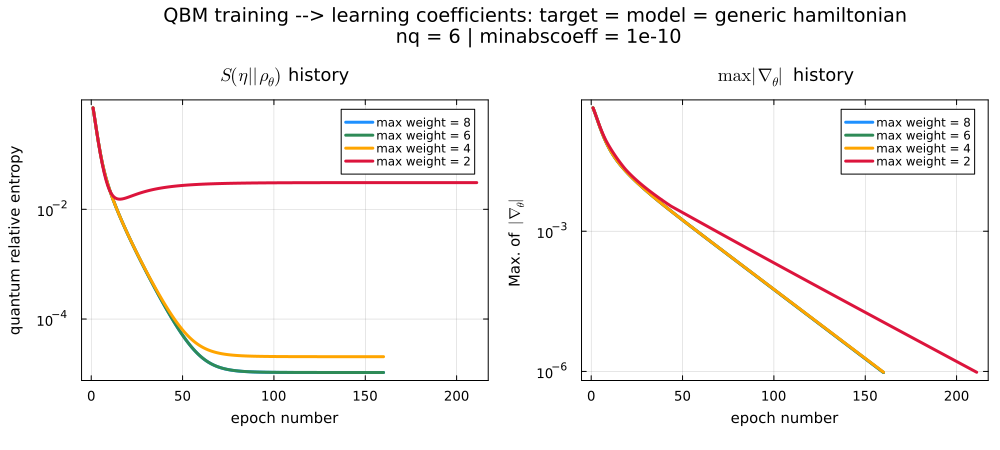

In [8]:
# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning coefficients: target = model = generic hamiltonian\n nq = 6 | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)

# XYZ Heisenberg

## 8 qubits

In [10]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 8  

# target

## target hamiltonian
target_beta = 1
rng = MersenneTwister(42)
field_scale = 0.5       # typical order of magnitude for 1-local terms
coupling_scale = 0.2    # typical order for 2-local terms
# Initialize all parameters randomly
params_target = parameters(
    :heisenberg_fields, nq;
    init = :randn,
    field_scale = field_scale,
    coupling_scale = coupling_scale,
    rng = rng
)
target_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) * target_beta

## target state
targert_circuit, target_θ = paulistringtocircuit(target_H_paulis)
num_layers_target = 10
max_weight_target = nq
min_abs_coeff_target = 1e-20
target_eta = makethermalstate(nq, targert_circuit, target_θ, num_layers_target;
                                  max_weight=max_weight_target,
                                  min_abs_coeff=min_abs_coeff_target)
target_eta_matrix = paulistringtomatrix(target_eta)
target_probs = computesymmetriceigenvalues(target_eta_matrix)

# beta values 
weight_values = [nq, nq-2, nq-4, nq-6]
colors = [:dodgerblue, :seagreen, :orange, :crimson]

# learning rate
gamma = 0.2
# number of epochs
epochs = 1000
# stop when gradient is smaller than epsilon
epsilon = 1e-6

beta = rand(rng, Uniform(0, 10))      

# # Output path
# save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
# base_name = "targetTFIM_qbmTFIM_6qb_notrunc"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over maximum weight values
for (i, max_weight_qbm) in enumerate(weight_values)

    println("\n" * "="^60)
    @printf("Starting optimization for max weight = %d\n", max_weight_qbm)
    println("="^60)

    # QBM model
    rng = MersenneTwister(3)
    field_scale = 0.5       # typical order of magnitude for 1-local terms
    coupling_scale = 0.2    # typical order for 2-local terms
    # Initialize all parameters randomly
    params = parameters(
        :heisenberg_fields, nq;
        init = :randn,
        field_scale = field_scale,
        coupling_scale = coupling_scale,
        rng = rng
    )
    qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta  
    ## truncation parameters
    num_layers_qbm = 10
    min_abs_coeff_qbm = 1e-10

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
        push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

        # create qbm state
        circuit, theta = paulistringtocircuit(qbm_H_paulis)
        rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # Compute and record gradient
        grads = computegradients(qbm_H_paulis, target_eta, rho)
        push!(grad_hist, abs.(grads))

        # Update parameters
        updatehamiltonian!(qbm_H_paulis, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 100 == 0
            @printf("  [w=%d | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    max_weight_qbm, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this maximum weight
    @printf("\nFinished max_weight = %d  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            max_weight_qbm, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # # ------------------------- #
    # # --- SAVE DATA TO FILE --- #
    # # ------------------------- #

    # # Save optimization histories as CSV
    # df = DataFrame(epoch = 1:length(qre_hist),
    #                qre = qre_hist,
    #                max_grad = [maximum(g) for g in grad_hist])
    # csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    # CSV.write(csv_path, df)
    # @printf("  → Saved CSV data to %s\n", csv_path)

    # # Collect metadata only once per run
    # metadata = Dict(
    #     "timestamp" => string(now()),
    #     "model_target" => "TFIM",
    #     "model_qbm" => "TFIM",
    #     "n_qubits" => nq,
    #     "beta_target" => target_beta,
    #     "beta_qbm" => beta,
    #     "beta_values" => beta_values,
    #     "learning_rate" => gamma,
    #     "epochs" => epochs,
    #     "epsilon" => epsilon,
    #     "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
    #                             "wij_xyz" => params_target.wij_xyz),
    #     "target_truncation" => Dict("max_weight" => max_weight_target,
    #                                 "min_abs_coeff" => min_abs_coeff_target,
    #                                 "num_layers" => num_layers_target),
    #     "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
    #                              "min_abs_coeff" => min_abs_coeff_qbm,
    #                              "num_layers" => num_layers_qbm)
    # )

    # json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    # JSON3.write(json_path, metadata; indent=2)
    # @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "max weight = $(max_weight_qbm)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "max weight = $(max_weight_qbm)", color = colors[i], lw = 3)
end


Starting optimization for max weight = 8
  [w=8 | epoch= 100]  QRE = 9.506608e-06   max|∇| = 5.746737e-04
Converged: max gradient < epsilon

Finished max_weight = 8  → epochs: 172 | final QRE = 7.620616e-06 | final max|∇| = 9.988e-07
------------------------------------------------------------

Starting optimization for max weight = 6
  [w=6 | epoch= 100]  QRE = 9.538117e-06   max|∇| = 5.806891e-04
Converged: max gradient < epsilon

Finished max_weight = 6  → epochs: 173 | final QRE = 7.620999e-06 | final max|∇| = 9.234e-07
------------------------------------------------------------

Starting optimization for max weight = 4
  [w=4 | epoch= 100]  QRE = 1.174719e-05   max|∇| = 7.662877e-04
Converged: max gradient < epsilon

Finished max_weight = 4  → epochs: 176 | final QRE = 8.411712e-06 | final max|∇| = 9.444e-07
------------------------------------------------------------

Starting optimization for max weight = 2
  [w=2 | epoch= 100]  QRE = 1.289433e-02   max|∇| = 1.352270e-02
  [w=

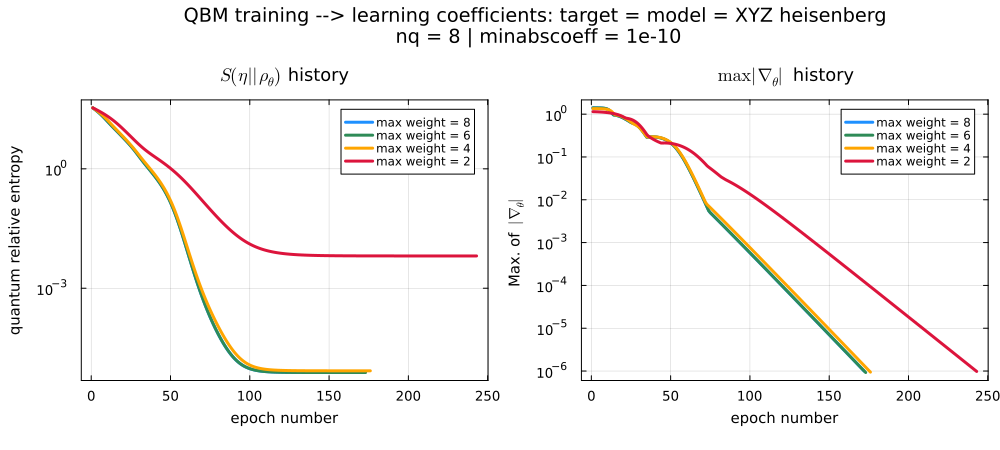

In [11]:
# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning coefficients: target = model = XYZ heisenberg\n nq = 8 | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)